In [1]:
#Importamos las librerías base
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

#Importamos las librerías propias
import MSAlib as msa

In [2]:
#Inicializamos las constantes del sistema
e0 = 1.60217662 * 1e-19		#Carga del electron (Coulombs)
kB = 1.38064852 * 1e-23		#Constante de Boltzmann m^2*kg/(K*s^2)  J/K
Av = 6.02214129 * 1e23		#Constante de Avogadro mol^(-1)
E0 = 8.8541878176 * 1e-12	#Permitividad en el vacio (C^2/(J*m))

#Ajustamos los parámetros iniciales y algunas variables
T = 298.0					#Temperatura absoluta en Kelvin (K)
Er = 78.5					#Constante dielectrica del agua a 25 °C

BETA = 1.0 / (kB * T)       #Tiene unidades de (1/J)
E = E0 * Er                 #Tiene unidades de (C^2/(J*m))

In [3]:
#Ajustamos el diámetro de las partículas, su valencia y concentración
#El número de especies viene dado por el tamaño del arreglo

R = np.array([1, 50., 70.])             #Diámetro de las partículas (en Å)
z = np.array([-1.25, 8.04, 15.44])      #Valencia de las especies (en unidades de carga protónica)

#Para la concentración podemos usar dos rutas:
#Ruta 1. Usar la concentración numérica (rho) en unidades de 1/(m^3)
#Pasamos de rho a phi
rho = np.array([32.52928, 4.03, 0.535]) * 1e24
phi = (np.pi/6.0)* rho * np.power(R, 3) * 1e-30
# print(phi)

#Ruta 2. Usar la fracción de volumen (phi)
#Pasamos de phi a rho
# phi = np.array([1.70322912e-05, 2.63762883e-01, 9.60829933e-02])
# rho = (6.0/np.pi) * phi * np.power(R, -3) * 1e30
# print(rho)

# X = phi / np.sum(phi)
# print("X  --->", X)

#Generamos el vector r (distancia en Å) y el vector de onda k
r = np.linspace(1e-3, 1000, 1000)
k = np.linspace(0, 10, 100000)

#Calculamos la función de correlación directa c(r)
Cij_r = msa.BuildCrMSA(r, z, rho, R, e0, E, BETA)
print("c(r) tensor DONE!")

#Calculamos la transformada de Fourier de la función de correlación directa c(k)
#El parámetro r[-1] es simplemente el rmax
Cij_k = msa.BuildCkMSA(k, z, rho, R, e0, E, BETA, r[-1])
print("C(k) tensor DONE!")

#Calculamos el factor de estructura S(k) empleando la Ec. 10 de https://doi.org/10.1063/1.441426
Sij_k = msa.BuildSkMSA(k, Cij_k, z, rho, R, e0, E, BETA, r[-1])
print("S(k) tensor DONE!")

#Calculamos la transformada de Fourier de la función de correlación total h(k)
Hij_k = msa.BuildHkMSA(Sij_k, rho)
print("H(k) tensor DONE!")

#Meramente por comparación, calculamos el factor de estructura S(k) empleando la relación S(k) = [I - rho*C(k)]^(-1)
Sij_k_noisy = msa.BuildSk(len(R), rho, Cij_k)
print("S(k) noisy tensor DONE!")

c(r) tensor DONE!
C(k) tensor DONE!
S(k) tensor DONE!
H(k) tensor DONE!
S(k) noisy tensor DONE!


In [4]:
nSpecies = len(rho)

rhoMat = np.zeros((nSpecies, nSpecies))
for i in range(nSpecies):
    for j in range(nSpecies):
        rhoMat[i, j] = np.sqrt(rho[i]*rho[j]) * 1e-30

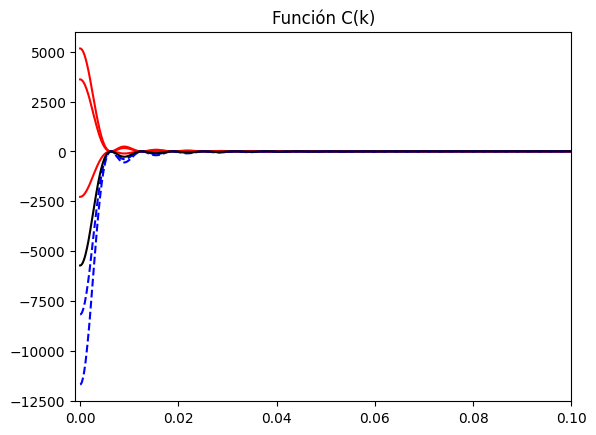

In [5]:
# GRAFICAR C(k), NOTE QUE C(k) ORIGINALMENTE TIENE UNIDADES DE m^3 POR LA TRANSFORMADA DE FOURIER

linetypes = ["r", "b--", "k"]

Cij_k_adim = np.zeros(Cij_k.shape)

for i in range(len(Cij_k[0,0,:])):
    Cij_k_adim[:,:,i] = rhoMat * Cij_k[:,:,i]

for i in range(len(R)):
    for j in range(i,len(R)):
        plt.plot(k, Cij_k_adim[i,j,:], linetypes[i])

plt.title("Función C(k)")

plt.xlim((-0.001, 0.1))
# plt.ylim((-10, 10))

plt.show()

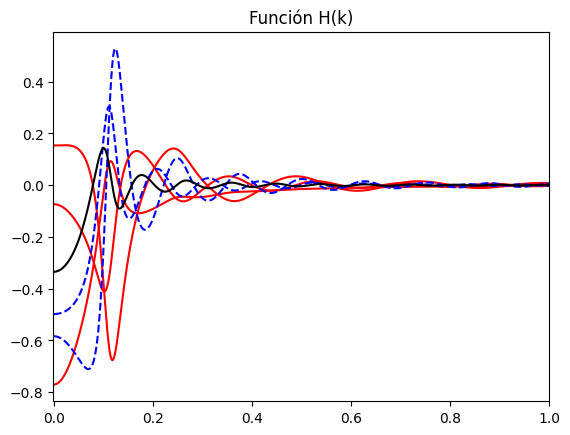

In [6]:
# GRAFICAR H(k), NOTE QUE H(k) ORIGINALMENTE TIENE UNIDADES DE m^3 POR LA TRANSFORMADA DE FOURIER

linetypes = ["r", "b--", "k"]

Hij_k_adim = np.zeros(Hij_k.shape)

for i in range(len(Hij_k[0,0,:])):
    Hij_k_adim[:,:,i] = rhoMat * Hij_k[:,:,i]

for i in range(len(R)):
    for j in range(i,len(R)):
        plt.plot(k, Hij_k_adim[i,j,:], linetypes[i])

plt.title("Función H(k)")

plt.xlim((-0.001, 1))
# plt.ylim((-10, 10))

plt.show()

In [7]:
#Cargamos datos del paper https://doi.org/10.1016/0378-4371(90)90263-R de Honorina Ruiz (Fig. 1a) para comparación y validación
with open("digitalizaciones/Sk/S11_Honorina_MSA.txt", "r") as f:
    S11 = np.loadtxt(f)

with open("digitalizaciones/Sk/S12_Honorina_MSA.txt", "r") as f:
    S12 = np.loadtxt(f)

with open("digitalizaciones/Sk/S22_Honorina_MSA.txt", "r") as f:
    S22 = np.loadtxt(f)

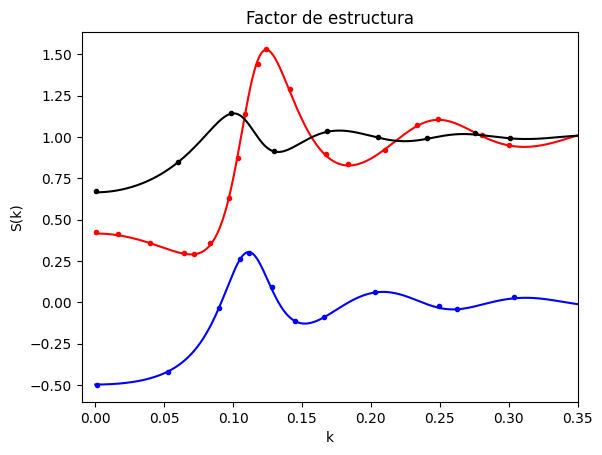

In [8]:
# GRAFICAR S(k), NOTE QUE S(k) ES ADIMENSIONAL

plt.plot(k, Sij_k[1,1,:], "r", label="Honorina")
plt.plot(S11[:,0], S11[:,1], "r.", label="Honorina")

plt.plot(k, Sij_k[1,2,:], "b", label="Honorina")
plt.plot(S12[:,0], S12[:,1], "b.", label="Honorina")

plt.plot(k, Sij_k[2,2,:], "k", label="Honorina")
plt.plot(S22[:,0], S22[:,1], "k.", label="Honorina")

plt.title("Factor de estructura")

plt.xlim((-0.01, 0.35))
# plt.ylim((-1, 2))

plt.xlabel("k")
plt.ylabel("S(k)")

plt.show()

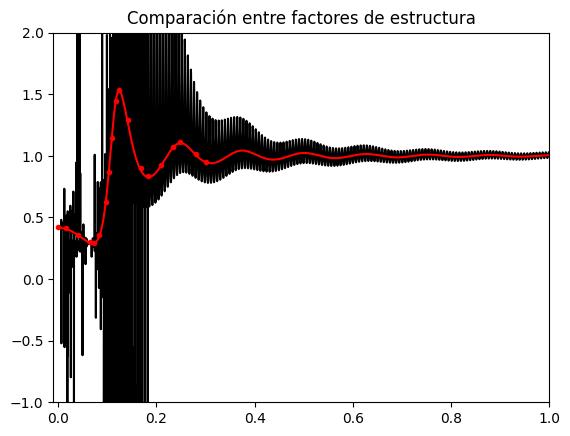

In [9]:
#Ahora haremos una comparación entre la función S(k) empleando el método que describe Medina-Noyola para fluidos cargados
#y empleando el método estándar de S(k) = [I - rho*C(k)]^(-1) (color negro)

plt.plot(k, Sij_k_noisy[1,1,:], "k")
plt.plot(k, Sij_k[1,1,:], "r")
plt.plot(S11[:,0], S11[:,1], "r.")

plt.title("Comparación entre factores de estructura")

plt.xlim((-0.01, 1))
plt.ylim((-1, 2))

plt.show()

In [10]:
#Calculamos la transformada de fourier de H(k) para recuperar la función de correlación total h(r)
#ESTA FUNCIÓN TARDA MUCHO EN EJECUTARSE

Hij_r = msa.BuildNumericHr(k, r, Hij_k, rho)

In [11]:
#Cargamos datos del paper https://doi.org/10.1016/0378-4371(90)90263-R de Honorina Ruiz (Fig. 1b) para comparación y validación

with open("digitalizaciones/hr/G11_Honorina_MSA.txt", "r") as f:
    G11 = np.loadtxt(f)

with open("digitalizaciones/hr/G12_Honorina_MSA.txt", "r") as f:
    G12 = np.loadtxt(f)

with open("digitalizaciones/hr/G22_Honorina_MSA.txt", "r") as f:
    G22 = np.loadtxt(f)

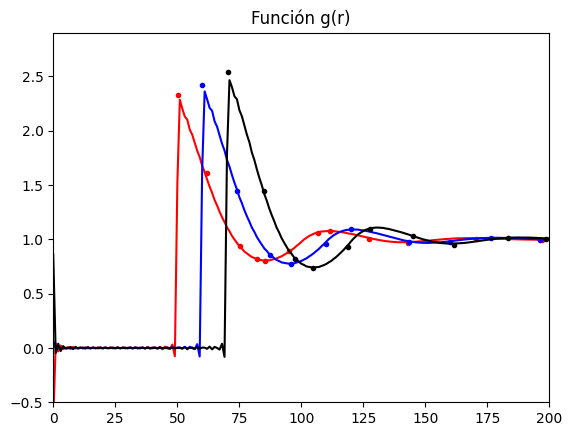

In [12]:
# GRAFICAR h(r), NOTE QUE h(r) ES ADIMENSIONAL

plt.plot(r, Hij_r[1,1,:]+1, "r")
plt.plot(G11[:,0], G11[:,1], "r.")

plt.plot(r, Hij_r[1,2,:]+1, "b")
plt.plot(G12[:,0], G12[:,1], "b.")

plt.plot(r, Hij_r[2,2,:]+1, "k")
plt.plot(G22[:,0], G22[:,1], "k.")

plt.title("Función g(r)")

plt.xlim((0, 200))
plt.ylim((-0.5, 2.9))

plt.show()

In [13]:
#Incluso podemos calcular el valor de la compresibilidad del sistema.

compresibility = msa.BuildCompressibility(r, Cij_r, rho)

print(f"Compresibilidad del sistema = {compresibility}")

Compresibilidad del sistema = 1.0200631067795927
